<a href="https://colab.research.google.com/github/KickGosu/AI-Trainning-Practice/blob/main/Bai%201.T%E1%BB%95ng%20quan%20AI/ML%20trong%20VH%20m%E1%BA%A1ng%20vi%E1%BB%85n%20th%C3%B4ng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài 1: Tổng quan AI/ML trong vận hành mạng viễn thông

Notebook này hướng dẫn các bước cơ bản để phân tích dữ liệu CDR (Call Detail Records) viễn thông:
- Đọc dữ liệu từ nhiều file CSV,
- Khám phá dữ liệu (EDA),
- Xử lý missing values,
- Phân tích hoạt động theo giờ,
- Trực quan hóa dữ liệu với matplotlib/seaborn.
- Xây dựng mô hình Linear Regression đầu tiên để dự đoán lưu lượng cuộc gọi từ dữ liệu SMS.


### Cấu trúc notebook

| Phần | Nội dung | Mục tiêu |
|------|----------|----------|
| **A** | Thiết lập môi trường | Cài đặt thư viện, import, kết nối Google Drive, tổ chức thư mục output |
| **B** | Khám phá dữ liệu CDR (EDA) | Giới thiệu dataset, đọc file, kiểm tra cấu trúc, thống kê mô tả, trực quan hóa cơ bản |
| **C** | Xử lý và phân tích dữ liệu | Gộp nhiều file, xử lý missing values, phân tích theo giờ, so sánh ngày/đêm, trong nước/quốc tế, phân tích tương quan |
| **D** | Xây dựng mô hình dự đoán | Train/val/test split, Linear Regression, đánh giá, lưu & load mô hình, trực quan hóa kết quả dự đoán |

Sau khi hoàn thành, người học sẽ nắm được: cách đọc và kiểm tra dữ liệu với pandas, xử lý missing values bằng mean, phân tích dữ liệu theo thời gian, phân biệt cuộc gọi trong nước và quốc tế, tính toán tương quan giữa các loại hoạt động, và xây dựng mô hình hồi quy tuyến tính đầu tiên với sklearn.

---
## Phần A: Thiết lập môi trường

## 1. Cài đặt thư viện

Cell này cài các thư viện phổ biến dùng xuyên suốt khóa học. Nếu môi trường đã có sẵn thư viện, bước này sẽ chạy rất nhanh.

In [ ]:
import sys
import subprocess

packages = ["pandas", "numpy", "matplotlib", "seaborn"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

print("Đã sẵn sàng môi trường thực hành.")

Đã sẵn sàng môi trường thực hành.


## 2. Import và cấu hình hiển thị

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Thư viện đã sẵn sàng!")

✅ Thư viện đã sẵn sàng!


## 3. Kết nối dữ liệu

Notebook ưu tiên đọc dữ liệu từ Google Drive nếu chạy trên Colab. Khi chạy trong workspace hiện tại, notebook sẽ tự dùng thư mục `data/` cục bộ. Dữ liệu được tải từ Kaggle: https://www.kaggle.com/datasets/marcodena/mobile-phone-activity

In [ ]:
# KAGGLE_KEY KGAT_39aa04968be7161f62e3bcd0d4109b14

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
LOCAL_DATA_ROOT = PROJECT_ROOT / "data"
DRIVE_DATA_ROOT = Path("/content/drive/MyDrive/CourseAI/data")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = DRIVE_DATA_ROOT if DRIVE_DATA_ROOT.exists() else LOCAL_DATA_ROOT
except Exception:
    DATA_ROOT = LOCAL_DATA_ROOT

print("DATA_ROOT:", DATA_ROOT)

Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/CourseAI/data


In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "Bai1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /content/notebooks/outputs/Bai1


---
## Phần B: Khám phá dữ liệu CDR (EDA)

## 4. Giới thiệu bộ dữ liệu CDR

### Tổng quan
Bộ dữ liệu Mobile Phone Activity ghi lại một tuần Call Details Records (CDR) tại Milan, Ý.

### Mô tả bộ dữ liệu
Mỗi khi người dùng thực hiện tương tác viễn thông, một Trạm Gốc Vô Tuyến (RBS - Radio Base Station) được nhà mạng chỉ định để truyền tải thông tin qua mạng. Khi đó, một bản ghi CDR mới được tạo, ghi lại thời gian tương tác và RBS đã xử lý nó.

Các hoạt động có trong bộ dữ liệu:

- Nhận SMS (received SMS)
- Gửi SMS (sent SMS)
- Cuộc gọi đến (incoming calls)
- Cuộc gọi đi (outgoing calls)
- Hoạt động Internet: Được tạo mỗi khi người dùng bắt đầu hoặc kết thúc kết nối Internet. Trong cùng một kết nối, một CDR được tạo nếu kết nối kéo dài hơn 15 phút hoặc người dùng truyền tải hơn 5 MB.

Dữ liệu được tổng hợp theo không gian trong lưới ô vuông. Khu vực gồm một lưới phủ 1,000 ô vuông với kích thước khoảng 235×235 mét mỗi ô.


## 5. Tải bộ dữ liệu từ Kaggle

Bộ dữ liệu được tải từ Kaggle. Dưới đây là cách kết nối Kaggle với Google Colab để tải dữ liệu tự động.

### Cách kết nối Kaggle với Google Colab

In [ ]:
# Phương pháp 1 (an toàn hơn, khuyên dùng)
# Lưu trữ thông tin xác thực trong Colab Secrets trước (xem hướng dẫn bên dưới)

from google.colab import userdata
import os

# Lưu thông tin xác thực vào biến môi trường
# os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Tải bộ dữ liệu từ Kaggle
!kaggle datasets download -d marcodena/mobile-phone-activity
!unzip mobile-phone-activity.zip

Dataset URL: https://www.kaggle.com/datasets/marcodena/mobile-phone-activity
License(s): DbCL-1.0
100% 242M/242M [00:01<00:00, 155MB/s]

Archive:  mobile-phone-activity.zip
  inflating: ISTAT_census_variables_2011.csv  
  inflating: Italian_provinces.geojson  
  inflating: mi-to-provinces-2013-11-01.csv  
  inflating: mi-to-provinces-2013-11-02.csv  
  inflating: mi-to-provinces-2013-11-03.csv  
  inflating: mi-to-provinces-2013-11-04.csv  
  inflating: mi-to-provinces-2013-11-05.csv  
  inflating: mi-to-provinces-2013-11-06.csv  
  inflating: mi-to-provinces-2013-11-07.csv  
  inflating: milano-grid.geojson     
  inflating: sms-call-internet-mi-2013-11-01.csv  
  inflating: sms-call-internet-mi-2013-11-02.csv  
  inflating: sms-call-internet-mi-2013-11-03.csv  
  inflating: sms-call-internet-mi-2013-11-04.csv  
  inflating: sms-call-internet-mi-2013-11-05.csv  
  inflating: sms-call-internet-mi-2013-11-06.csv  
  inflating: sms-call-internet-mi-2013-11-07.csv  


## 6. Quan sát thư mục dữ liệu

Trước khi đọc dữ liệu, ta nên xem trong thư mục có những file nào. Đây là thói quen quan trọng khi nhận một dataset mới.

### Câu hỏi khởi động:

- Có tổng cộng bao nhiêu file?
- Bạn nhận xét gì về tên file?
- Tại sao có 7 file cho mỗi loại SMS/calls/internet?
- 'mi-to-provinces' có thể có ý nghĩa gì?
- File nào có dung lượng lớn nhất?

## 7. Đọc và khám phá dữ liệu một ngày

Bắt đầu bằng việc đọc dữ liệu của một ngày để làm quen với cấu trúc.

In [ ]:
# Liệt kê tất cả file dữ liệu trong thư mục hiện tại
files = [f for f in os.listdir() if f.endswith('.csv') or f.endswith('.geojson')]
print('*'*70)
print(f"Nội dung thư mục: Tìm thấy {len(files)} file dữ liệu:")
print('*'*70)
for i, f in enumerate(sorted(files), 1):
    size = os.path.getsize(f) / 1024**2  # Kích thước tính bằng MB
    print(f"  {i:2d}. {f:50s} ({size:6.2f} MB)")

**********************************************************************
Nội dung thư mục: Tìm thấy 17 file dữ liệu:
**********************************************************************
   1. ISTAT_census_variables_2011.csv                    (  0.08 MB)
   2. Italian_provinces.geojson                          (  7.66 MB)
   3. mi-to-provinces-2013-11-01.csv                     ( 94.09 MB)
   4. mi-to-provinces-2013-11-02.csv                     ( 93.68 MB)
   5. mi-to-provinces-2013-11-03.csv                     ( 86.78 MB)
   6. mi-to-provinces-2013-11-04.csv                     (133.25 MB)
   7. mi-to-provinces-2013-11-05.csv                     (137.29 MB)
   8. mi-to-provinces-2013-11-06.csv                     (137.76 MB)
   9. mi-to-provinces-2013-11-07.csv                     (136.75 MB)
  10. milano-grid.geojson                                (  3.02 MB)
  11. sms-call-internet-mi-2013-11-01.csv                ( 79.40 MB)
  12. sms-call-internet-mi-2013-11-02.csv              

In [ ]:
# Đọc file dữ liệu SMS/call/internet ngày 01-11-2013
# import pandas as pd
cdr_df = pd.read_csv("sms-call-internet-mi-2013-11-01.csv")
cdr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891928 entries, 0 to 1891927
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   CellID       int64  
 2   countrycode  int64  
 3   smsin        float64
 4   smsout       float64
 5   callin       float64
 6   callout      float64
 7   internet     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 115.5+ MB


In [ ]:
# Xem 10 dòng đầu tiên
print("\n10 dòng đầu tiên:")
cdr_df.head(10)


10 dòng đầu tiên:


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-01 00:00:00,1,0,0.3521,NaN,NaN,0.0273,NaN
1,2013-11-01 00:00:00,1,33,NaN,NaN,NaN,NaN,0.0261
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
3,2013-11-01 00:00:00,2,0,0.3581,NaN,NaN,0.0273,NaN
4,2013-11-01 00:00:00,2,33,NaN,NaN,NaN,NaN,0.0274
5,2013-11-01 00:00:00,2,39,1.7334,1.0880,0.6020,0.4109,57.8875
6,2013-11-01 00:00:00,3,0,0.3644,NaN,NaN,0.0273,NaN
7,2013-11-01 00:00:00,3,33,NaN,NaN,NaN,NaN,0.0287
8,2013-11-01 00:00:00,3,39,1.7348,1.0701,0.6128,0.4203,58.0095
9,2013-11-01 00:00:00,4,0,0.3349,NaN,NaN,0.0273,NaN


## 8. Khám phá cấu trúc dữ liệu

Kiểm tra các thông tin cơ bản: kích thước, tên cột, kiểu dữ liệu và thống kê mô tả.

In [ ]:
# Khám phá cơ bản
print(f"\nKích thước tập dữ liệu: {cdr_df.shape[0]:,} dòng × {cdr_df.shape[1]} cột")

print(f"\nCác cột:")
for col in cdr_df.columns:
    print(f"   - {col}")

print("\nKiểu dữ liệu:")
print(cdr_df.dtypes)

print(f"\nThống kê mô tả:")
cdr_df.describe()


Kích thước tập dữ liệu: 1,891,928 dòng × 8 cột

Các cột:
   - datetime
   - CellID
   - countrycode
   - smsin
   - smsout
   - callin
   - callout
   - internet

Kiểu dữ liệu:
datetime        object
CellID           int64
countrycode      int64
smsin          float64
smsout         float64
callin         float64
callout        float64
internet       float64
dtype: object

Thống kê mô tả:


,CellID,countrycode,smsin,smsout,callin,callout,internet
count,1.891928e+06,1.891928e+06,805775.000000,469482.000000,484147.000000,854515.000000,804854.000000
mean,5.277812e+03,3.538213e+02,5.716717,6.011796,5.417363,3.741025,102.477277
std,2.719573e+03,4.287521e+03,15.503784,16.953823,15.915312,13.986531,342.024253
min,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.153000e+03,3.300000e+01,0.129300,0.109600,0.075200,0.060700,0.058300
50%,5.387000e+03,4.100000e+01,0.772400,0.755200,0.385000,0.236900,0.230200
75%,7.492000e+03,8.600000e+01,4.468400,4.627375,3.179100,1.206000,42.447725
max,1.000000e+04,9.725900e+04,1109.082000,1577.903800,988.576700,1024.899200,27774.298900


### Câu hỏi:
- Mỗi dòng trong dữ liệu đại diện cho điều gì?

## 9. Khám phá sâu hơn về cấu trúc dữ liệu

In [ ]:
# Tìm hiểu cấu trúc dữ liệu kỹ hơn

print("\n" + "="*70)
print("TÌM HIỂU CẤU TRÚC DỮ LIỆU")
print("="*70)

# Có bao nhiêu ô lưới?
print(f"\nTổng số ô lưới (không unique - CID): {len(cdr_df['CellID'])}")

print(f"Số ô lưới duy nhất (CID): {cdr_df['CellID'].nunique()}")
# Có thể dùng cách khác:
# print(f"Có bao nhiêu CID khác nhau: {len(cdr_df['CellID'].value_counts())}")

# Quan sát một ô lưới cụ thể
sample_cid = cdr_df['CellID'].iloc[0]
print(f"\nÔ lưới mẫu: {sample_cid}\n")

# Chỉ xem dữ liệu của một ô lưới duy nhất (CID=1)
print(f"\nDữ liệu của ô lưới CID = 1:")
single_cid_1 = cdr_df[cdr_df['CellID'] == sample_cid]
single_cid_1


TÌM HIỂU CẤU TRÚC DỮ LIỆU

Tổng số ô lưới (không unique - CID): 1891928
Số ô lưới duy nhất (CID): 10000

Ô lưới mẫu: 1


Dữ liệu của ô lưới CID = 1:


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-01 00:00:00,1,0,0.3521,NaN,NaN,0.0273,NaN
1,2013-11-01 00:00:00,1,33,NaN,NaN,NaN,NaN,0.0261
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
54581,2013-11-01 01:00:00,1,0,0.1378,NaN,NaN,0.0309,NaN
54582,2013-11-01 01:00:00,1,39,1.0259,0.7700,0.1906,0.1633,44.0469
...,...,...,...,...,...,...,...,...
1757405,2013-11-01 22:00:00,1,48,0.0261,NaN,NaN,NaN,NaN
1829008,2013-11-01 23:00:00,1,0,0.4205,NaN,NaN,0.0523,NaN
1829009,2013-11-01 23:00:00,1,1,0.0261,NaN,NaN,NaN,NaN
1829010,2013-11-01 23:00:00,1,39,1.8767,1.4788,0.3539,0.6070,58.8158


In [ ]:
# Kiểm tra lại rằng ta chỉ đang xem đúng một CID
cdr_df[cdr_df['CellID'] == sample_cid].CellID.value_counts()

## 10. Câu hỏi phân tích

- Các hoạt động khác nhau trong CDR là gì?
- CDR này ghi nhận cuộc gọi đến và đi từ những quốc gia nào? Liệt kê tất cả.
- Có bao nhiêu cuộc gọi đến, bao nhiêu cuộc gọi đi?

## 11. Tập trung phân tích một ô lưới CID 1

In [ ]:
# Hiển thị toàn bộ dữ liệu của CID 1
single_cid_1

,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-01 00:00:00,1,0,0.3521,NaN,NaN,0.0273,NaN
1,2013-11-01 00:00:00,1,33,NaN,NaN,NaN,NaN,0.0261
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
54581,2013-11-01 01:00:00,1,0,0.1378,NaN,NaN,0.0309,NaN
54582,2013-11-01 01:00:00,1,39,1.0259,0.7700,0.1906,0.1633,44.0469
...,...,...,...,...,...,...,...,...
1757405,2013-11-01 22:00:00,1,48,0.0261,NaN,NaN,NaN,NaN
1829008,2013-11-01 23:00:00,1,0,0.4205,NaN,NaN,0.0523,NaN
1829009,2013-11-01 23:00:00,1,1,0.0261,NaN,NaN,NaN,NaN
1829010,2013-11-01 23:00:00,1,39,1.8767,1.4788,0.3539,0.6070,58.8158


In [ ]:
# Lọc các dòng có SMS đi (smsout không NaN)
sms_out = single_cid_1['smsout'].notna()
sms_outgoing = single_cid_1[sms_out]
print(f"   Kích thước dữ liệu chỉ chứa SMS đi (không NaN): {sms_outgoing.shape}")
sms_outgoing

   Kích thước dữ liệu chỉ chứa SMS đi (không NaN): (35, 8)


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
54582,2013-11-01 01:00:00,1,39,1.0259,0.7700,0.1906,0.1633,44.0469
100058,2013-11-01 02:00:00,1,39,0.3883,0.3004,0.0279,0.1360,41.1798
138762,2013-11-01 03:00:00,1,39,1.1248,0.8957,0.0018,0.0261,33.0221
177160,2013-11-01 04:00:00,1,39,0.3491,0.5112,0.0054,0.0261,31.3769
215340,2013-11-01 05:00:00,1,39,0.1135,0.1954,0.0279,0.1319,34.8155
257255,2013-11-01 06:00:00,1,39,0.1093,0.1158,0.2168,0.1045,35.4161
306793,2013-11-01 07:00:00,1,39,0.5813,0.2447,0.2435,0.4946,42.9335
369987,2013-11-01 08:00:00,1,0,1.4571,0.0273,0.0523,0.0179,NaN
369988,2013-11-01 08:00:00,1,39,2.2078,1.4093,1.1086,1.2328,59.8808


## 12. Trực quan hóa dữ liệu SMS

In [ ]:
# Chuyển đổi cột datetime thành kiểu datetime và trích xuất ngày, giờ
sms_outgoing['datetime'] = pd.to_datetime(sms_outgoing['datetime'])  # Chuyển sang kiểu datetime

sms_outgoing['date'] = sms_outgoing['datetime'].dt.date
sms_outgoing['hour'] = sms_outgoing['datetime'].dt.hour
sms_outgoing.columns

/tmp/ipykernel_2946/4205999887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms_outgoing['datetime'] = pd.to_datetime(sms_outgoing['datetime'])  # Chuyển sang kiểu datetime
/tmp/ipykernel_2946/4205999887.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms_outgoing['date'] = sms_outgoing['datetime'].dt.date
/tmp/ipykernel_2946/4205999887.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

Index(['datetime', 'CellID', 'countrycode', 'smsin', 'smsout', 'callin',
       'callout', 'internet', 'date', 'hour'],
      dtype='object')

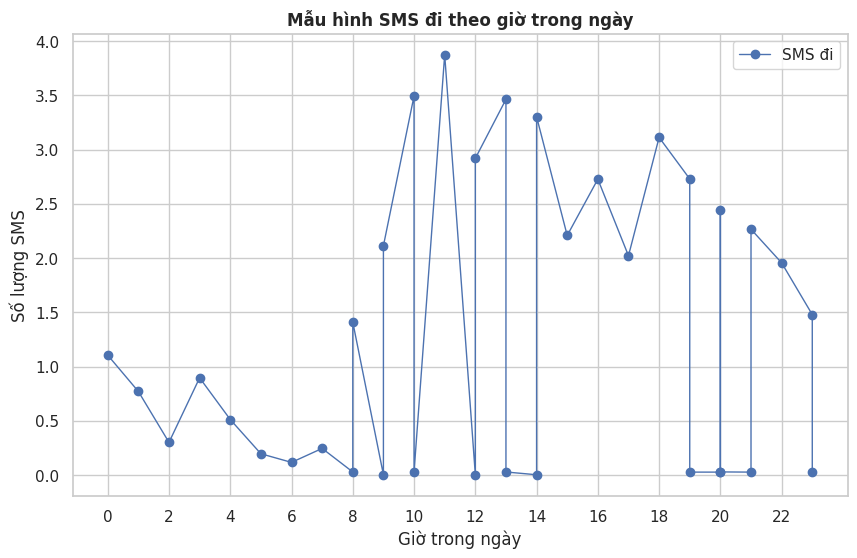

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))

#

# Vẽ biểu đồ dữ liệu thô
plt.plot(sms_outgoing['hour'], sms_outgoing['smsout'], marker='o', linewidth=1, markersize=6, label='SMS đi')
plt.title('Mẫu hình SMS đi theo giờ trong ngày', fontweight='bold', fontsize=12)
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng SMS')
plt.xticks(range(0, 24, 2))
plt.grid(True)
plt.legend();

## 13. Thực hành: Chọn một ô lưới khác và tìm giờ cao điểm SMS của ô đó

---
## Phần C: Xử lý và phân tích dữ liệu


### NHIỆM VỤ 1: Tải và gộp dữ liệu

1. Tải 3 file dữ liệu hoạt động SMS/call/internet (sms-call-internet-mi-2013-11-02.csv,
sms-call-internet-mi-2013-11-04.csv, sms-call-internet-mi-2013-11-06.csv) và gộp chúng lại.

2. Tạo một tập dữ liệu sạch, sẵn sàng cho phân tích.

#### Yêu cầu:
- Tải cả 3 file hoạt động
- Thêm cột ngày và giờ
- Gộp vào một dataframe duy nhất
- Xử lý missing values (Gợi ý: Điền bằng giá trị trung bình)
- Thêm cột tổng hợp (total_sms, total_calls, total_internet)

#### Câu hỏi:
- Có tổng cộng bao nhiêu bản ghi trên cả 3 tập dữ liệu?
- Có bao nhiêu ô lưới (CellID) duy nhất?
- Có bao nhiêu mã quốc gia (countrycode) xuất hiện trong dữ liệu?
- Có missing values không?
  - Nếu có, điền missing/NaN bằng giá trị trung bình của mỗi cột.
  - Cột nào có nhiều missing values nhất?
  - Bạn đã chỉnh sửa bao nhiêu bản ghi?

- Giờ cao điểm phổ biến nhất trên tất cả các ô lưới là gì?
  - Giờ nào có hoạt động thấp nhất?
  - Tính toán và báo cáo: mean, median, std, min, max cho tổng số cuộc gọi theo giờ

- Tỷ lệ phần trăm tổng hoạt động diễn ra vào ban ngày (6h-20h) so với ban đêm (20h-6h)?

- Cuộc gọi quốc tế có diễn ra vào các khung giờ khác với cuộc gọi trong nước không? (so sánh mẫu hình theo giờ)

- Sử dụng numpy để thực hiện so sánh thống kê giữa các điều kiện khác nhau.

  So sánh:
    1. Cuộc gọi trong nước (Ý) vs Quốc tế.
        - Tỷ lệ phần trăm cuộc gọi quốc tế so với trong nước? (5đ)
        - Tỷ lệ phần trăm SMS quốc tế so với trong nước? (5đ)
        - Cuộc gọi quốc tế có xu hướng đến hay đi nhiều hơn (tính tỷ lệ)? (5đ)
    2. Các loại hoạt động khác nhau.
        - Có tương quan giữa khối lượng SMS và khối lượng Cuộc gọi ở cấp độ ô lưới không? (5đ)

## 14. Tải và gộp 3 file dữ liệu hoạt động

Tải 3 file: sms-call-internet-mi-2013-11-02.csv, sms-call-internet-mi-2013-11-04.csv, sms-call-internet-mi-2013-11-06.csv và gộp chúng lại.

In [ ]:
# Tải 3 file dữ liệu hoạt động SMS/call/internet
sms_call_internet_02_df = pd.read_csv("sms-call-internet-mi-2013-11-02.csv")
print(sms_call_internet_02_df.info())
sms_call_internet_02_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847331 entries, 0 to 1847330
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   CellID       int64  
 2   countrycode  int64  
 3   smsin        float64
 4   smsout       float64
 5   callin       float64
 6   callout      float64
 7   internet     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 112.8+ MB
None


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-02 00:00:00,1,0,0.2445,NaN,NaN,NaN,NaN
1,2013-11-02 00:00:00,1,39,1.4952,1.1213,0.2708,0.3004,46.5094
2,2013-11-02 00:00:00,1,53,0.0018,0.0036,NaN,NaN,NaN


In [ ]:
sms_call_internet_04_df = pd.read_csv("sms-call-internet-mi-2013-11-04.csv")
print(sms_call_internet_04_df.info())
sms_call_internet_04_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2299544 entries, 0 to 2299543
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   CellID       int64  
 2   countrycode  int64  
 3   smsin        float64
 4   smsout       float64
 5   callin       float64
 6   callout      float64
 7   internet     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 140.4+ MB
None


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-04 00:00:00,1,0,0.1080,NaN,NaN,NaN,NaN
1,2013-11-04 00:00:00,1,39,1.0266,0.8069,0.0552,0.2155,50.342
2,2013-11-04 00:00:00,2,0,0.1093,NaN,NaN,NaN,NaN


In [ ]:
sms_call_internet_06_df = pd.read_csv("sms-call-internet-mi-2013-11-06.csv")
print(sms_call_internet_06_df.info())
sms_call_internet_06_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2417156 entries, 0 to 2417155
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   datetime     object 
 1   CellID       int64  
 2   countrycode  int64  
 3   smsin        float64
 4   smsout       float64
 5   callin       float64
 6   callout      float64
 7   internet     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 147.5+ MB
None


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-06 00:00:00,1,0,0.0814,NaN,NaN,NaN,NaN
1,2013-11-06 00:00:00,1,39,0.7458,0.7204,0.1626,0.1057,52.3219
2,2013-11-06 00:00:00,2,0,0.0829,NaN,NaN,NaN,NaN


### Gộp vào một dataframe duy nhất

In [ ]:
# Gộp 3 dataframe vào một dataframe duy nhất
combined_df = pd.concat([sms_call_internet_02_df, sms_call_internet_04_df, sms_call_internet_06_df], ignore_index=True)


## 15. Tạo tập dữ liệu sạch, sẵn sàng phân tích

Thêm cột ngày và giờ từ cột datetime.

In [ ]:
# Chuyển đổi cột datetime từ object sang datetime và trích xuất ngày, giờ vào cột mới
combined_df['datetime'] = pd.to_datetime(combined_df['datetime'])
combined_df['date'] = combined_df['datetime'].dt.date
combined_df['time'] = combined_df['datetime'].dt.time
combined_df.tail()

,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet,date,time
6564026,2013-11-06 23:00:00,10000,32,NaN,NaN,NaN,NaN,0.0860,2013-11-06,23:00:00
6564027,2013-11-06 23:00:00,10000,34,0.5160,0.4300,NaN,NaN,NaN,2013-11-06,23:00:00
6564028,2013-11-06 23:00:00,10000,39,4.5423,4.8837,0.901,0.2675,101.0942,2013-11-06,23:00:00
6564029,2013-11-06 23:00:00,10000,41,NaN,NaN,0.086,NaN,NaN,2013-11-06,23:00:00
6564030,2013-11-06 23:00:00,10000,221,NaN,NaN,NaN,0.2580,NaN,2013-11-06,23:00:00


### Có tổng cộng bao nhiêu bản ghi trên cả 3 tập dữ liệu?

In [ ]:
# Tổng số bản ghi (dòng) trong tập dữ liệu đã gộp
print("Tổng số bản ghi:", combined_df.shape[0])

Tổng số bản ghi: 6564031


### Có bao nhiêu ô lưới (CellID) duy nhất?

In [ ]:
# Số lượng ô lưới duy nhất (CellID)
print("Số ô lưới duy nhất (CellID):", combined_df['CellID'].nunique())

Số ô lưới duy nhất (CellID): 10000


### Có bao nhiêu mã quốc gia (countrycode) xuất hiện trong dữ liệu?

In [ ]:
# Số lượng mã quốc gia duy nhất trong dữ liệu
print("Số mã quốc gia duy nhất trong dữ liệu:", combined_df['countrycode'].nunique())

Số mã quốc gia duy nhất trong dữ liệu: 302


## 16. Kiểm tra và xử lý missing values

### Có missing values không?

- Nếu có, điền missing/NaN bằng giá trị trung bình của mỗi cột.
- Cột nào có nhiều missing values nhất?
- Bạn đã chỉnh sửa bao nhiêu bản ghi?

In [ ]:
# Kiểm tra số lượng missing values trong mỗi cột
combined_df.isna().sum()

,0
datetime,0
CellID,0
countrycode,0
smsin,3964171
smsout,5025738
callin,4761685
callout,3764484
internet,3621117
date,0
time,0


### Xử lý missing values: Điền bằng giá trị trung bình

In [ ]:
print('Số lượng missing values trước khi điền:')
print(combined_df[['smsin', 'smsout', 'callin', 'callout', 'internet']].isnull().sum())

# Điền missing values bằng giá trị trung bình của mỗi cột
modified_count = 0  # Biến đếm số giá trị đã được điền

for col in ['smsin', 'smsout', 'callin', 'callout', 'internet']:
    original_nans = combined_df[col].isnull().sum()
    combined_df[col] = combined_df[col].fillna(combined_df[col].mean())
    modified_count += (original_nans - combined_df[col].isnull().sum())

print(f"\nSố lượng bản ghi đã được điền: {modified_count}")

print('\nSố lượng missing values sau khi điền:')
print(combined_df[['smsin', 'smsout', 'callin', 'callout', 'internet']].isnull().sum())

Số lượng missing values trước khi điền:
smsin       3964171
smsout      5025738
callin      4761685
callout     3764484
internet    3621117
dtype: int64

Số lượng bản ghi đã được điền: 21137195

Số lượng missing values sau khi điền:
smsin       0
smsout      0
callin      0
callout     0
internet    0
dtype: int64


* Cột **smsout** có nhiều missing values nhất, với 5,025,738 giá trị thiếu.
* Chúng ta đã chỉnh sửa tổng cộng 21,137,195 bản ghi.

## 17. Thêm cột tổng hợp

Tạo các cột tổng hợp để phân tích: tổng SMS, tổng cuộc gọi và tổng Internet.

In [ ]:
# Thêm các cột tổng hợp cho tổng sms, tổng cuộc gọi và tổng hoạt động internet
combined_df['total_sms'] = combined_df['smsin'] + combined_df['smsout']
combined_df['total_calls'] = combined_df['callin'] + combined_df['callout']
combined_df['total_internet'] = combined_df['internet']

# combined_df.head()

## 18. Phân tích hoạt động theo giờ

### Giờ cao điểm phổ biến nhất trên tất cả các ô lưới là gì?

In [ ]:
# Trích xuất giờ từ cột datetime
combined_df['hour'] = combined_df['datetime'].dt.hour
print("Đã thêm cột 'hour' vào combined_df:")
combined_df[['datetime', 'hour']].head()

Đã thêm cột 'hour' vào combined_df:


,datetime,hour
0,2013-11-02,0
1,2013-11-02,0
2,2013-11-02,0
3,2013-11-02,0
4,2013-11-02,0


In [ ]:
# Tính tổng hoạt động theo giờ: tổng của total_sms, total_calls và total_internet cho mỗi giờ
hourly_activity = combined_df.groupby('hour')[['total_sms', 'total_calls', 'total_internet']].sum().reset_index()
hourly_activity['total_activity_hourly'] = hourly_activity['total_sms'] + hourly_activity['total_calls'] + hourly_activity['total_internet']
print("Đã tổng hợp hoạt động theo giờ và tính tổng hoạt động:")
hourly_activity.head()

Đã tổng hợp hoạt động theo giờ và tính tổng hoạt động:


,hour,total_sms,total_calls,total_internet,total_activity_hourly
0,0,1.793529e+06,1.544151e+06,1.686987e+07,2.020755e+07
1,1,1.256787e+06,1.185631e+06,1.318190e+07,1.562431e+07
2,2,1.044790e+06,1.028140e+06,1.110928e+07,1.318221e+07
3,3,9.772733e+05,9.711108e+05,9.912125e+06,1.186051e+07
4,4,1.127516e+06,1.100273e+06,9.549219e+06,1.177701e+07


### Giờ cao điểm:

In [ ]:
hourly_activity['total_activity_hourly'].idxmax()

17

In [ ]:
# Tìm giờ có hoạt động cao nhất
peak_hour = hourly_activity.loc[hourly_activity['total_activity_hourly'].idxmax()]

print(f"Giờ cao điểm: {int(peak_hour['hour'])}h - Tổng hoạt động: {peak_hour['total_activity_hourly']:.2f}")

Giờ cao điểm: 17h - Tổng hoạt động: 51477440.53


### Giờ có hoạt động thấp nhất:

In [ ]:
hourly_activity['total_activity_hourly'].idxmin()

4

In [ ]:
# Tìm giờ có hoạt động thấp nhất
lowest_hour = hourly_activity.loc[hourly_activity['total_activity_hourly'].idxmin()]

print(f"Giờ thấp nhất: {int(lowest_hour['hour'])}h - Tổng hoạt động: {lowest_hour['total_activity_hourly']:.2f}")

Giờ thấp nhất: 4h - Tổng hoạt động: 11777007.39


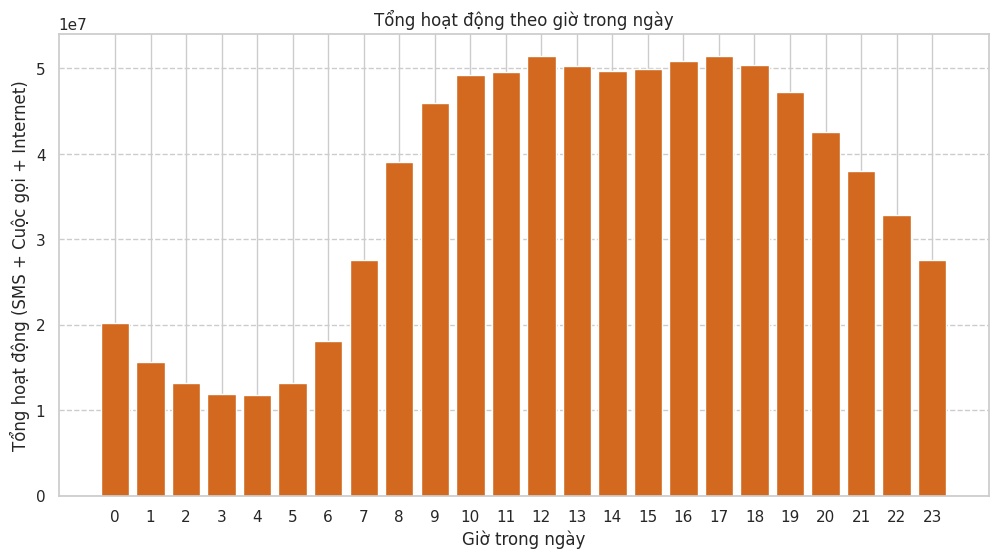

In [ ]:
# Vẽ biểu đồ tổng hoạt động theo giờ
plt.figure(figsize=(12, 6))
plt.bar(hourly_activity['hour'], hourly_activity['total_activity_hourly'], color='chocolate')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tổng hoạt động (SMS + Cuộc gọi + Internet)')
plt.title('Tổng hoạt động theo giờ trong ngày')
plt.xticks(hourly_activity['hour'])
plt.grid(axis='y', linestyle='--')
plt.show()

### Thống kê mô tả cho tổng số cuộc gọi theo giờ

Tính toán và báo cáo: mean, median, std, min, max cho total_calls theo từng giờ.

In [ ]:
print("\nThống kê mô tả cho tổng số cuộc gọi theo giờ:")
calls_by_hour_stats_per_hour = combined_df.groupby('hour')['total_calls'].agg(['mean', 'median', 'std', 'min', 'max'])
calls_by_hour_stats_per_hour


Thống kê mô tả cho tổng số cuộc gọi theo giờ:


,mean,median,std,min,max
hour,,,,,
0,10.280157,13.425298,5.279040,0.0002,223.4941
1,9.928661,13.425298,5.129893,0.0000,141.9847
2,9.894713,13.425298,5.329786,0.0000,210.9691
3,9.953373,13.425298,5.649571,0.0000,298.3541
4,10.235666,13.425298,5.294288,0.0000,255.0555
5,10.029019,13.425298,5.395003,0.0000,177.1690
6,10.339697,13.425298,4.969421,0.0002,201.3488
7,11.464472,13.425298,8.435423,0.0000,412.7314
8,13.272816,13.425298,22.237365,0.0000,1122.7091


## 19. So sánh hoạt động ban ngày và ban đêm

### Tỷ lệ phần trăm tổng hoạt động vào ban ngày (6h-20h) so với ban đêm (20h-6h)?

In [ ]:
# Phân loại mỗi giờ vào 'daytime' (6h đến trước 20h) hoặc 'nighttime' (20h đến trước 6h)
hourly_activity['time_period'] = hourly_activity['hour'].apply(lambda x: 'daytime' if 6 <= x < 20 else 'nighttime')
print("Hoạt động theo giờ với cột 'time_period':")
hourly_activity.head()

Hoạt động theo giờ với cột 'time_period':


,hour,total_sms,total_calls,total_internet,total_activity_hourly,time_period
0,0,1.793529e+06,1.544151e+06,1.686987e+07,2.020755e+07,nighttime
1,1,1.256787e+06,1.185631e+06,1.318190e+07,1.562431e+07,nighttime
2,2,1.044790e+06,1.028140e+06,1.110928e+07,1.318221e+07,nighttime
3,3,9.772733e+05,9.711108e+05,9.912125e+06,1.186051e+07,nighttime
4,4,1.127516e+06,1.100273e+06,9.549219e+06,1.177701e+07,nighttime


In [ ]:
# Tính tổng hoạt động cho mỗi khoảng thời gian
time_period_activity = hourly_activity.groupby('time_period')['total_activity_hourly'].sum().reset_index()
print("Tổng hoạt động theo khoảng thời gian:")
time_period_activity

Tổng hoạt động theo khoảng thời gian:


,time_period,total_activity_hourly
0,daytime,6.310280e+08
1,nighttime,2.269183e+08


In [ ]:
# Tính tổng hoạt động toàn bộ
overall_total_activity = time_period_activity['total_activity_hourly'].sum()
print(f"Tổng hoạt động toàn bộ: {overall_total_activity:.2f}")

Tổng hoạt động toàn bộ: 857946276.41


In [ ]:
# Tính tỷ lệ phần trăm hoạt động cho ban ngày và ban đêm
time_period_activity['percentage_of_total_activity'] = (time_period_activity['total_activity_hourly'] / overall_total_activity) * 100
print("Hoạt động theo khoảng thời gian với tỷ lệ phần trăm:")
time_period_activity

Hoạt động theo khoảng thời gian với tỷ lệ phần trăm:


,time_period,total_activity_hourly,percentage_of_total_activity
0,daytime,6.310280e+08,73.550987
1,nighttime,2.269183e+08,26.449013


* 73.6% lưu lượng diễn ra vào ban ngày
* 26.4% lưu lượng diễn ra vào ban đêm

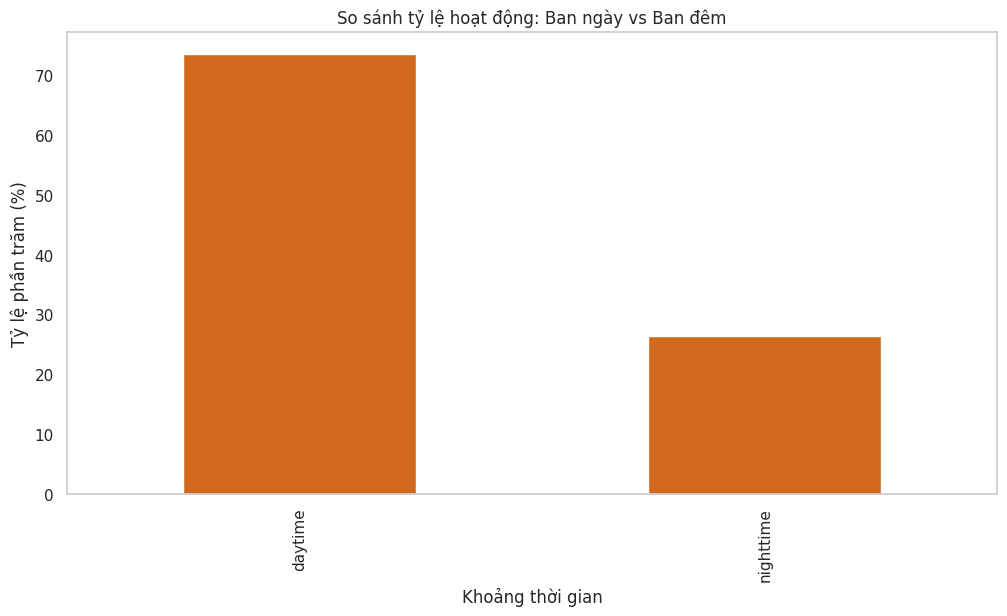

In [ ]:
# Vẽ biểu đồ so sánh tỷ lệ phần trăm
time_period_activity_df = time_period_activity.set_index('time_period')

time_period_activity_df['percentage_of_total_activity'].plot(kind='bar', legend=False, color='chocolate')
plt.title('So sánh tỷ lệ hoạt động: Ban ngày vs Ban đêm')
plt.xlabel('Khoảng thời gian')
plt.ylabel('Tỷ lệ phần trăm (%)')
plt.grid()
plt.show()

## 20. So sánh cuộc gọi trong nước và quốc tế

### Cuộc gọi quốc tế có diễn ra vào các khung giờ khác với cuộc gọi trong nước không?

Sử dụng numpy để thực hiện so sánh thống kê giữa các điều kiện khác nhau.

So sánh: Cuộc gọi trong nước (Ý - countrycode=39) vs Quốc tế.

In [ ]:
# Tạo cột 'call_type' để phân loại cuộc gọi trong nước hay quốc tế
combined_df['call_type'] = np.where(combined_df['countrycode'] == 39, 'Trong nước', 'Quốc tế')

# Tạo cột 'sms_type' để phân loại SMS trong nước hay quốc tế
combined_df['sms_type'] = np.where(combined_df['countrycode'] == 39, 'Trong nước', 'Quốc tế')

print("Đã thêm cột 'call_type' và 'sms_type' vào combined_df:")
combined_df[['countrycode', 'call_type', 'sms_type']].head()

Đã thêm cột 'call_type' và 'sms_type' vào combined_df:


,countrycode,call_type,sms_type
0,0,Quốc tế,Quốc tế
1,39,Trong nước,Trong nước
2,53,Quốc tế,Quốc tế
3,0,Quốc tế,Quốc tế
4,39,Trong nước,Trong nước


In [ ]:
# Trích xuất dữ liệu cuộc gọi theo giờ và loại cuộc gọi
hourly_calls = combined_df.groupby(['hour', 'call_type'])['total_calls'].sum().reset_index()
print("Khối lượng cuộc gọi theo giờ, nhóm theo loại cuộc gọi:")
hourly_calls.head()

Khối lượng cuộc gọi theo giờ, nhóm theo loại cuộc gọi:


,hour,call_type,total_calls
0,0,Quốc tế,1.404073e+06
1,0,Trong nước,1.400787e+05
2,1,Quốc tế,1.088012e+06
3,1,Trong nước,9.761930e+04
4,2,Quốc tế,9.120028e+05


In [ ]:
# Xem dữ liệu cuộc gọi trong nước
hourly_calls[hourly_calls['call_type'] == 'Trong nước']['total_calls']

,total_calls
1,1.400787e+05
3,9.761930e+04
5,1.161369e+05
7,1.307244e+05
9,1.293069e+05
11,9.228045e+04
13,1.175235e+05
15,4.414562e+05
17,1.222819e+06
19,1.960100e+06


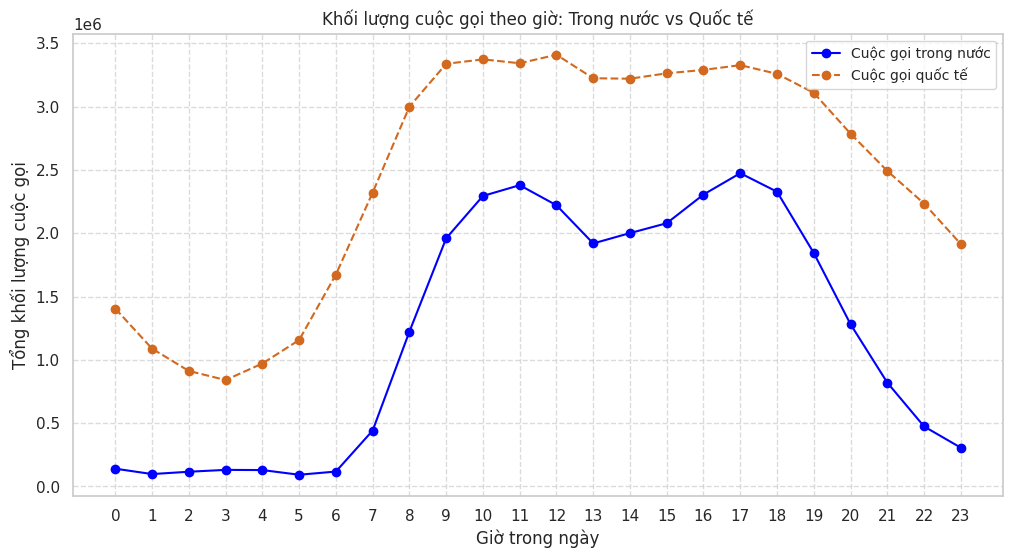

In [ ]:
# Vẽ biểu đồ so sánh mẫu hình cuộc gọi theo giờ giữa trong nước và quốc tế
plt.figure(figsize=(12, 6))

# Vẽ đường cuộc gọi trong nước
plt.plot(hourly_calls[hourly_calls['call_type'] == 'Trong nước']['hour'],
         hourly_calls[hourly_calls['call_type'] == 'Trong nước']['total_calls'],
         label='Cuộc gọi trong nước', marker='o', linestyle='-', color='blue')

# Vẽ đường cuộc gọi quốc tế
plt.plot(hourly_calls[hourly_calls['call_type'] == 'Quốc tế']['hour'],
         hourly_calls[hourly_calls['call_type'] == 'Quốc tế']['total_calls'],
         label='Cuộc gọi quốc tế', marker='o', linestyle='--', color='chocolate')

plt.title('Khối lượng cuộc gọi theo giờ: Trong nước vs Quốc tế')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tổng khối lượng cuộc gọi')
plt.xticks(range(0, 24))  # Hiển thị tất cả các giờ
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

In [ ]:
# Tính tổng số cuộc gọi theo loại (trong nước / quốc tế)
call_type_totals = combined_df.groupby('call_type')['total_calls'].sum().reset_index()
print("Tổng khối lượng cuộc gọi theo loại:")
call_type_totals

Tổng khối lượng cuộc gọi theo loại:


,call_type,total_calls
0,Quốc tế,5.894984e+07
1,Trong nước,2.917423e+07


### Tỷ lệ phần trăm cuộc gọi quốc tế so với trong nước?

In [ ]:
# Tính tỷ lệ phần trăm cuộc gọi cho cả hai loại trong nước và quốc tế
overall_total_calls = call_type_totals['total_calls'].sum()
call_type_totals['percentage'] = (call_type_totals['total_calls'] / overall_total_calls) * 100

print("Tỷ lệ phần trăm cuộc gọi theo loại:")
call_type_totals

Tỷ lệ phần trăm cuộc gọi theo loại:


,call_type,total_calls,percentage
0,Quốc tế,5.894984e+07,66.894142
1,Trong nước,2.917423e+07,33.105858


* Tỷ lệ cuộc gọi trong nước: 33.1%
* Tỷ lệ cuộc gọi quốc tế: 66.9%

### Tỷ lệ phần trăm SMS quốc tế so với trong nước?

In [ ]:
# Tính tổng SMS theo loại (trong nước / quốc tế)
sms_type_totals = combined_df.groupby('sms_type')['total_sms'].sum().reset_index()
print("Tổng khối lượng SMS theo loại:")
sms_type_totals

Tổng khối lượng SMS theo loại:


,sms_type,total_sms
0,Quốc tế,7.535462e+07
1,Trong nước,2.509296e+07


In [ ]:
# Tính tỷ lệ phần trăm SMS trong nước và quốc tế
overall_total_sms = sms_type_totals['total_sms'].sum()

sms_type_totals['percentage'] = (sms_type_totals['total_sms'] / overall_total_sms) * 100

print("Tỷ lệ phần trăm SMS theo loại:")
sms_type_totals

Tỷ lệ phần trăm SMS theo loại:


,sms_type,total_sms,percentage
0,Quốc tế,7.535462e+07,75.018855
1,Trong nước,2.509296e+07,24.981145


* Tỷ lệ SMS trong nước: 25%
* Tỷ lệ SMS quốc tế: 75%

### Cuộc gọi quốc tế có xu hướng đến hay đi nhiều hơn? (tính tỷ lệ)

In [ ]:
# Lọc cuộc gọi quốc tế và xác định cuộc gọi quốc tế đến nhiều hay đi nhiều hơn
international_calls = combined_df[combined_df['call_type'] == 'Quốc tế']

total_international_callin = international_calls['callin'].sum()
total_international_callout = international_calls['callout'].sum()

print(f"Tổng cuộc gọi quốc tế đến: {total_international_callin:.2f}")
print(f"Tổng cuộc gọi quốc tế đi: {total_international_callout:.2f}")

if total_international_callout > 0:
    ratio_incoming_to_outgoing = total_international_callin / total_international_callout
    print(f"Tỷ lệ cuộc gọi quốc tế đến / đi: {ratio_incoming_to_outgoing:.2f}")
else:
    print("Không có cuộc gọi quốc tế đi để tính tỷ lệ.")

Tổng cuộc gọi quốc tế đến: 36911800.81
Tổng cuộc gọi quốc tế đi: 22038040.62
Tỷ lệ cuộc gọi quốc tế đến / đi: 1.67


## 21. Phân tích tương quan giữa các loại hoạt động

### Có tương quan giữa khối lượng SMS và khối lượng Cuộc gọi ở cấp độ ô lưới không?

In [ ]:
# Tính tương quan giữa cột tổng hợp 'total_sms' và 'total_calls' theo từng ô lưới
cell_activity = combined_df.groupby('CellID')[['total_sms', 'total_calls']].sum().reset_index()

correlation = cell_activity['total_sms'].corr(cell_activity['total_calls'])

print(f"Tương quan giữa khối lượng SMS và khối lượng Cuộc gọi ở cấp độ ô lưới: {correlation:.2f}")

Tương quan giữa khối lượng SMS và khối lượng Cuộc gọi ở cấp độ ô lưới: 0.99


In [ ]:
# Tính ma trận tương quan cho 'total_sms' và 'total_calls'
correlation_matrix = cell_activity[['total_sms', 'total_calls']].corr()

print("Ma trận tương quan:")
correlation_matrix

Ma trận tương quan:


,total_sms,total_calls
total_sms,1.000000,0.986235
total_calls,0.986235,1.000000


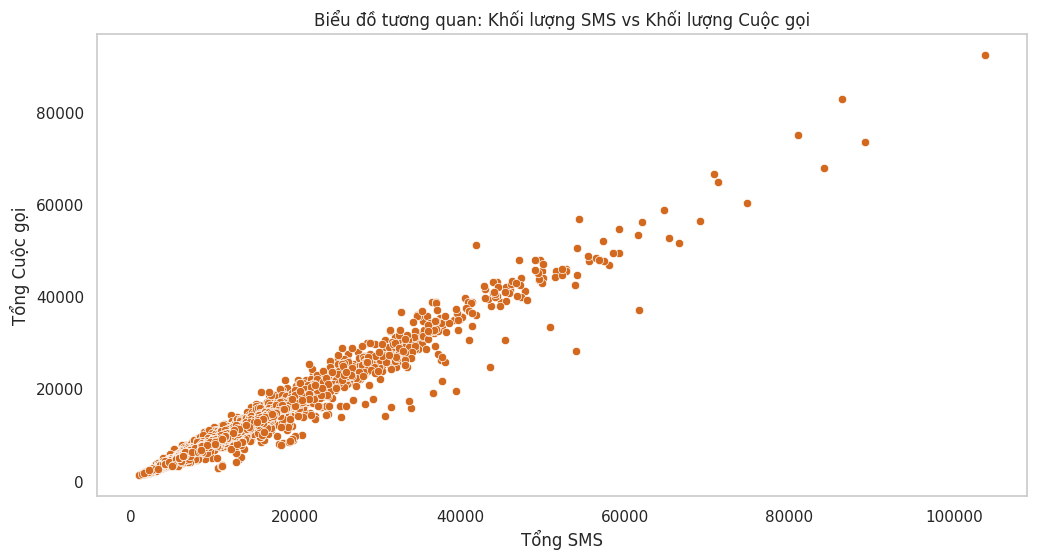

In [ ]:
import seaborn as sns

# Vẽ biểu đồ tương quan giữa SMS và Cuộc gọi
plt.figure(figsize=(12, 6))
sns.scatterplot(data=cell_activity, x='total_sms', y='total_calls', color='chocolate')
plt.title('Biểu đồ tương quan: Khối lượng SMS vs Khối lượng Cuộc gọi')
plt.xlabel('Tổng SMS')
plt.ylabel('Tổng Cuộc gọi')
plt.grid()
plt.show()

Có mối tương quan rất cao giữa SMS và Cuộc gọi ở cấp độ ô lưới (0.99). Điều này được thể hiện qua giá trị tương quan và được xác nhận bởi biểu đồ phân tán.

Ý nghĩa: Các ô lưới có lưu lượng SMS cao thì cũng có xu hướng có lưu lượng cuộc gọi cao. Điều này phản ánh mật độ dân cư và mức độ sử dụng dịch vụ viễn thông tại từng khu vực.

---
## Phần D: Xây dựng mô hình dự đoán

## 22. Dự đoán tổng số cuộc gọi từ tổng số SMS với Linear Regression

Ở phần trước, ta đã phát hiện mối tương quan rất mạnh giữa `total_sms` và `total_calls` (r = 0.99). Điều này gợi ý rằng ta có thể xây dựng một mô hình hồi quy tuyến tính đơn giản để dự đoán tổng số cuộc gọi từ tổng số SMS tại mỗi ô lưới.

Trong phần này, ta sẽ:
- Chuẩn bị dữ liệu đầu vào (X = total_sms) và biến mục tiêu (y = total_calls)
- Chia dữ liệu thành 3 tập: train (70%), validation (15%), test (15%)
- Huấn luyện mô hình Linear Regression từ sklearn
- Đánh giá mô hình trên tập validation và test
- Lưu mô hình và load lại để dự đoán
- Trực quan hóa kết quả dự đoán

## 23. Import thư viện sklearn và chuẩn bị dữ liệu

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Chuẩn bị dữ liệu: X là total_sms, y là total_calls
# Lưu ý: X cần ở dạng 2D cho sklearn (DataFrame), y ở dạng 1D (Series)
X = cell_activity[['total_sms']]
y = cell_activity['total_calls']

print(f"Kích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")
print(f"\nMột vài dòng đầu của X:")
X.head()

Kích thước X: (10000, 1)
Kích thước y: (10000,)

Một vài dòng đầu của X:


,total_sms
0,3660.014242
1,3666.749942
2,3144.500052
3,3640.510942
4,3727.018236


In [ ]:
# Xem phân bố của biến mục tiêu
print("Thống kê mô tả của y (total_calls):")
y.describe()

Thống kê mô tả của y (total_calls):


,total_calls
count,10000.000000
mean,8812.407134
std,6311.820475
min,1362.961520
25%,5207.079931
50%,7185.213454
75%,10252.027503
max,92429.740423


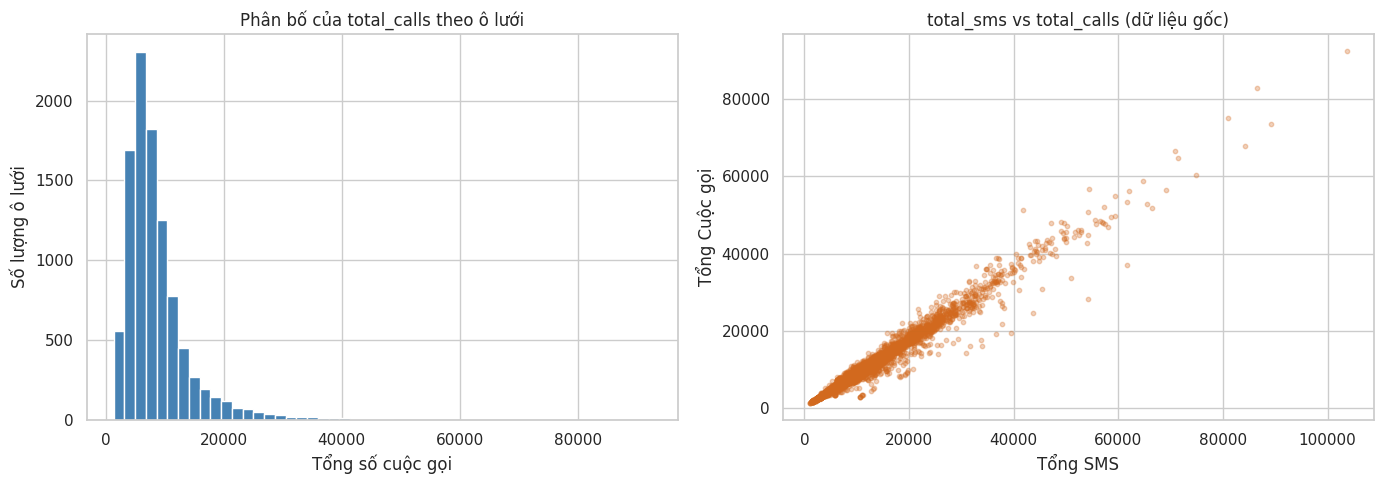

In [ ]:
# Trực quan hóa phân bố của biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Phân bố của total_calls theo ô lưới')
axes[0].set_xlabel('Tổng số cuộc gọi')
axes[0].set_ylabel('Số lượng ô lưới')

axes[1].scatter(X, y, alpha=0.3, color='chocolate', s=10)
axes[1].set_title('total_sms vs total_calls (dữ liệu gốc)')
axes[1].set_xlabel('Tổng SMS')
axes[1].set_ylabel('Tổng Cuộc gọi')

plt.tight_layout()
plt.show()

## 24. Chia tập train / validation / test

Ta chia dữ liệu thành 3 tập với tỷ lệ 70% train, 15% validation, 15% test. Tập validation dùng để đánh giá mô hình trong quá trình huấn luyện, tập test chỉ dùng để đánh giá cuối cùng.

In [ ]:
# Bước 1: Tách 70% train, 30% tạm (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Bước 2: Tách 30% tạm thành 15% validation và 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Tập Train:   {X_train.shape[0]:,} mẫu ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Tập Validation: {X_val.shape[0]:,} mẫu ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Tập Test:    {X_test.shape[0]:,} mẫu ({X_test.shape[0]/len(X)*100:.0f}%)")

Tập Train:   7,000 mẫu (70%)
Tập Validation: 1,500 mẫu (15%)
Tập Test:    1,500 mẫu (15%)


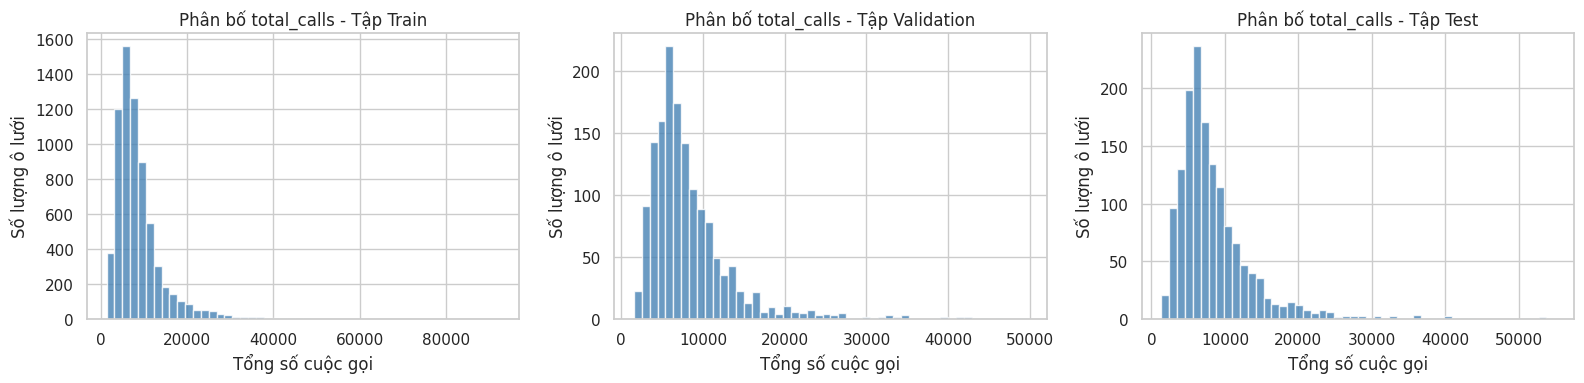

In [ ]:
# Kiểm tra phân bố của y trên các tập
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (y_data, title) in zip(
    axes,
    [(y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')]
):
    ax.hist(y_data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'Phân bố total_calls - Tập {title}')
    ax.set_xlabel('Tổng số cuộc gọi')
    ax.set_ylabel('Số lượng ô lưới')

plt.tight_layout()
plt.show()

## 25. Huấn luyện mô hình Linear Regression

Linear Regression là mô hình hồi quy tuyến tính cơ bản nhất: nó tìm một đường thẳng $y = w \cdot x + b$ khớp nhất với dữ liệu. Với bài toán của ta: `total_calls = w * total_sms + b`.

In [ ]:
# Khởi tạo và huấn luyện mô hình
model = LinearRegression()
model.fit(X_train, y_train)

# Hệ số của mô hình
print(f"Hệ số góc (w - slope):     {model.coef_[0]:.6f}")
print(f"Hệ số chặn (b - intercept): {model.intercept_:.4f}")
print(f"\nPhương trình hồi quy: total_calls = {model.coef_[0]:.6f} * total_sms + {model.intercept_:.4f}")

Hệ số góc (w - slope):     0.866372
Hệ số chặn (b - intercept): 108.7034

Phương trình hồi quy: total_calls = 0.866372 * total_sms + 108.7034


## 26. Đánh giá mô hình

Đánh giá mô hình trên cả 3 tập bằng các chỉ số: MSE (Mean Squared Error), MAE (Mean Absolute Error), và R² Score.

In [ ]:
# Hàm đánh giá mô hình
def evaluate_model(model, X_data, y_data, dataset_name):
    """Đánh giá mô hình và in kết quả."""
    y_pred = model.predict(X_data)
    mse = mean_squared_error(y_data, y_pred)
    mae = mean_absolute_error(y_data, y_pred)
    r2 = r2_score(y_data, y_pred)

    print(f"--- {dataset_name} ---")
    print(f"  MSE:  {mse:,.2f}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {np.sqrt(mse):,.2f}")
    print(f"  R²:   {r2:.6f}")
    print()
    return y_pred, mse, mae, r2

# Đánh giá trên cả 3 tập
y_train_pred, train_mse, train_mae, train_r2 = evaluate_model(model, X_train, y_train, "Train")
y_val_pred, val_mse, val_mae, val_r2 = evaluate_model(model, X_val, y_val, "Validation")
y_test_pred, test_mse, test_mae, test_r2 = evaluate_model(model, X_test, y_test, "Test")

--- Train ---
  MSE:  1,132,926.51
  MAE:  541.80
  RMSE: 1,064.39
  R²:   0.973226

--- Validation ---
  MSE:  835,939.28
  MAE:  486.77
  RMSE: 914.30
  R²:   0.974279

--- Test ---
  MSE:  1,137,816.92
  MAE:  534.44
  RMSE: 1,066.69
  R²:   0.967872



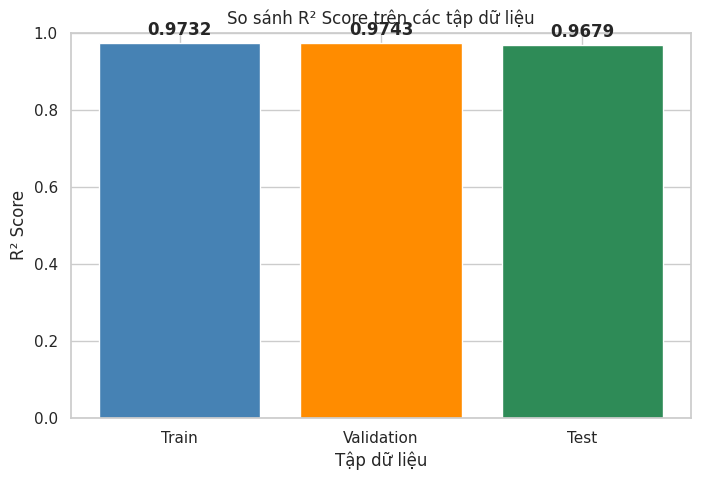

In [ ]:
# So sánh R² trên 3 tập
r2_scores = pd.DataFrame({
    'Tập dữ liệu': ['Train', 'Validation', 'Test'],
    'R² Score': [train_r2, val_r2, test_r2]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(r2_scores['Tập dữ liệu'], r2_scores['R² Score'], color=['steelblue', 'darkorange', 'seagreen'])
plt.title('So sánh R² Score trên các tập dữ liệu')
plt.xlabel('Tập dữ liệu')
plt.ylabel('R² Score')
plt.ylim(0, 1)

# Thêm giá trị lên trên mỗi cột
for bar, score in zip(bars, r2_scores['R² Score']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()

## 27. Lưu mô hình

Lưu mô hình đã huấn luyện để sử dụng sau này mà không cần train lại. Ta lưu vào thư mục checkpoints trên Google Drive (nếu chạy Colab) hoặc thư mục output cục bộ.

In [ ]:
# Tạo thư mục checkpoints nếu chưa có
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = CHECKPOINT_DIR / "bai1_linear_regression_sms_calls.joblib"

# Lưu mô hình
joblib.dump(model, MODEL_PATH)

print(f"Đã lưu mô hình tại: {MODEL_PATH}")
print(f"Kích thước file: {MODEL_PATH.stat().st_size:,} bytes")

Đã lưu mô hình tại: /content/notebooks/outputs/Bai1/checkpoints/bai1_linear_regression_sms_calls.joblib
Kích thước file: 817 bytes


In [ ]:
# Kiểm tra file đã tồn tại
print(f"File tồn tại: {MODEL_PATH.exists()}")

File tồn tại: True


## 28. Load mô hình từ checkpoint và dự đoán

Minh họa quy trình thực tế: load mô hình đã lưu và dự đoán trên dữ liệu mới.

In [ ]:
# Load mô hình từ file
loaded_model = joblib.load(MODEL_PATH)

# Kiểm tra mô hình đã load đúng chưa
print(f"Hệ số góc (w):     {loaded_model.coef_[0]:.6f}")
print(f"Hệ số chặn (b):   {loaded_model.intercept_:.4f}")

Hệ số góc (w):     0.866372
Hệ số chặn (b):   108.7034


### 29.2 Dự đoán trên toàn bộ tập test và trực quan hóa

In [ ]:
# Dự đoán trên toàn bộ tập test
y_test_pred_all = loaded_model.predict(X_test)

# Tạo dataframe kết quả
test_results = pd.DataFrame({
    'total_sms': X_test['total_sms'].values,
    'total_calls_thuc_te': y_test.values,
    'total_calls_du_doan': y_test_pred_all,
    'sai_so': y_test.values - y_test_pred_all
})
test_results['sai_so_tuyet_doi'] = np.abs(test_results['sai_so'])
test_results.head(10)

,total_sms,total_calls_thuc_te,total_calls_du_doan,sai_so,sai_so_tuyet_doi
0,5841.208495,4423.480352,5169.363641,-745.883289,745.883289
1,24198.887455,19687.638056,21073.945044,-1386.306988,1386.306988
2,13710.563061,11288.374865,11987.153110,-698.778245,698.778245
3,7439.099296,7146.807486,6553.731697,593.075790,593.075790
4,5292.594228,4438.305866,4694.059531,-255.753665,255.753665
5,7435.604419,6388.504200,6550.703832,-162.199633,162.199633
6,10016.228284,9713.165824,8786.484424,926.681400,926.681400
7,10204.133819,9298.800605,8949.280543,349.520062,349.520062
8,10096.420839,8497.013727,8855.961018,-358.947292,358.947292
9,12311.852408,9734.095206,10775.349184,-1041.253977,1041.253977


In [ ]:
# Thống kê sai số trên tập test
print("Thống kê sai số trên tập test:")
print(f"  Sai số tuyệt đối trung bình (MAE): {test_results['sai_so_tuyet_doi'].mean():,.2f}")
print(f"  Sai số tuyệt đối lớn nhất:         {test_results['sai_so_tuyet_doi'].max():,.2f}")
print(f"  Sai số tuyệt đối nhỏ nhất:         {test_results['sai_so_tuyet_doi'].min():,.4f}")
print(f"  Độ lệch chuẩn của sai số:          {test_results['sai_so_tuyet_doi'].std():,.2f}")

### Trực quan hóa 1: Biểu đồ phân tán Thực tế vs Dự đoán

Nếu mô hình hoàn hảo, tất cả các điểm sẽ nằm trên đường chéo (y = x).

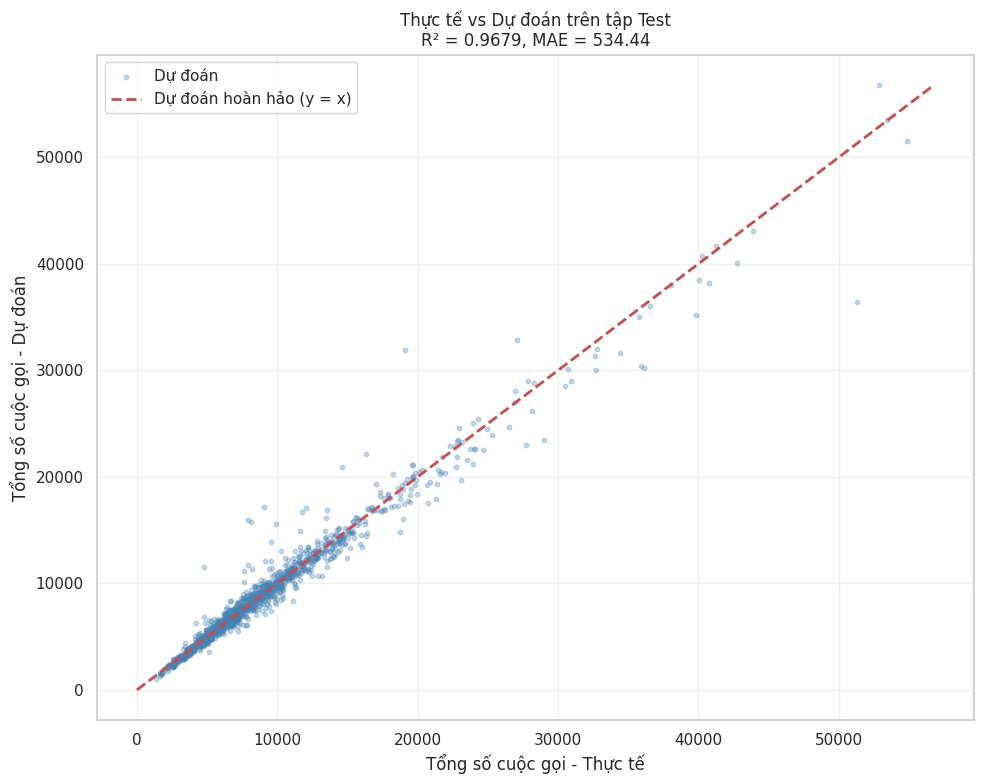

In [ ]:
plt.figure(figsize=(10, 8))

# Vẽ scatter plot
plt.scatter(test_results['total_calls_thuc_te'], test_results['total_calls_du_doan'],
            alpha=0.3, s=10, color='steelblue', label='Dự đoán')

# Vẽ đường chéo hoàn hảo (y = x)
max_val = max(test_results['total_calls_thuc_te'].max(), test_results['total_calls_du_doan'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Dự đoán hoàn hảo (y = x)')

plt.xlabel('Tổng số cuộc gọi - Thực tế')
plt.ylabel('Tổng số cuộc gọi - Dự đoán')
plt.title(f'Thực tế vs Dự đoán trên tập Test\nR² = {test_r2:.4f}, MAE = {test_mae:,.2f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Trực quan hóa 2: Phân bố sai số

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram của sai số
axes[0].hist(test_results['sai_so'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Sai số = 0')
axes[0].set_title('Phân bố sai số dự đoán trên tập Test')
axes[0].set_xlabel('Sai số (thực tế - dự đoán)')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].legend()

# Scatter plot của sai số theo giá trị thực tế
axes[1].scatter(test_results['total_calls_thuc_te'], test_results['sai_so'],
                alpha=0.3, s=10, color='chocolate')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Sai số theo giá trị thực tế')
axes[1].set_xlabel('Tổng số cuộc gọi - Thực tế')
axes[1].set_ylabel('Sai số (thực tế - dự đoán)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Trực quan hóa 3: Đường hồi quy trên dữ liệu test

Vẽ đường hồi quy của mô hình chồng lên dữ liệu test để thấy độ khớp.

In [ ]:
plt.figure(figsize=(10, 7))

# Dữ liệu test
plt.scatter(X_test, y_test, alpha=0.3, s=15, color='steelblue', label='Dữ liệu Test (thực tế)')

# Đường hồi quy
x_line = np.linspace(X_test['total_sms'].min(), X_test['total_sms'].max(), 100).reshape(-1, 1)
y_line = loaded_model.predict(pd.DataFrame(x_line, columns=['total_sms']))
plt.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Đường hồi quy: y = {model.coef_[0]:.4f}x + {model.intercept_:.2f}')

plt.xlabel('Tổng SMS')
plt.ylabel('Tổng Cuộc gọi')
plt.title('Đường hồi quy Linear Regression trên tập Test')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 29. Nhận xét về mô hình

Từ kết quả trên, ta rút ra một số nhận xét:

- **R² ≈ 0.97**: Mô hình giải thích được khoảng 97% phương sai của `total_calls` từ `total_sms`. Điều này khẳng định lại mối tương quan rất mạnh (0.99) mà ta đã phát hiện ở phần EDA.
- **R² đồng đều trên cả 3 tập** (train/validation/test): Mô hình không bị overfitting - nó học được mối quan hệ thực sự, không chỉ ghi nhớ dữ liệu train.
- **Sai số tập trung quanh 0**: Phân bố sai số có dạng hình chuông, đối xứng quanh 0 - dấu hiệu của một mô hình hồi quy tuyến tính phù hợp.
- **Ứng dụng thực tế**: Với mô hình này, nhà mạng có thể ước tính nhanh lưu lượng cuộc gọi tại một ô lưới chỉ từ dữ liệu SMS, hỗ trợ việc quy hoạch dung lượng mạng.

## 30. Tổng kết bài 1

Trong bài này, chúng ta đã đi qua quy trình phân tích dữ liệu viễn thông cơ bản với Pandas và xây dựng mô hình dự đoán đầu tiên:

- **Đọc và kiểm tra dữ liệu**: Sử dụng `pd.read_csv` để đọc file dữ liệu CDR, kiểm tra kích thước, kiểu dữ liệu và cấu trúc.
- **EDA (Exploratory Data Analysis)**: Khám phá phân bố dữ liệu, thống kê mô tả, trực quan hóa với matplotlib và seaborn.
- **Xử lý dữ liệu thiếu**: Phát hiện và điền missing values bằng giá trị trung bình cho 5 cột hoạt động chính (tổng cộng hơn 21 triệu giá trị được điền).
- **Tạo đặc trưng mới**: Trích xuất ngày, giờ từ cột datetime; tạo cột tổng hợp total_sms, total_calls, total_internet.
- **Phân tích theo thời gian**: Xác định giờ cao điểm (17h) và giờ thấp điểm (4h); so sánh hoạt động ban ngày (73.6%) và ban đêm (26.4%).
- **Phân tích cuộc gọi trong nước và quốc tế**: 66.9% cuộc gọi là quốc tế; tỷ lệ cuộc gọi quốc tế đến/đi là 1.67 (đến nhiều hơn đi).
- **Phân tích tương quan**: SMS và Cuộc gọi có tương quan rất mạnh (r=0.99) ở cấp độ ô lưới.
- **Xây dựng mô hình Linear Regression**: Dự đoán total_calls từ total_sms với R² ≈ 0.97; lưu và load mô hình với joblib; trực quan hóa kết quả dự đoán.

Những kỹ năng này là nền tảng cho các bài học tiếp theo về feature engineering và xây dựng mô hình học máy trên dữ liệu viễn thông.